In [3]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [4]:
import torch
from nanodrz.model import DiarizeGPT, Config
from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play
from nanodrz.download import dl_scp_file

ckpt = torch.load(dl_scp_file("gpudev:runs/nanodrz/nanodrz/1705840799/0037000.pt"))

rsync --partial --progress --human-readable -e ssh gpudev:runs/nanodrz/nanodrz/1705840799/0037000.pt /home/harry/.cache/nanodrz/runs/nanodrz/nanodrz/1705840799/0037000.pt
0037000.pt

              0   0%    0.00kB/s    0:00:00  
        575.20M  46%  310.79MB/s    0:00:02  
          1.12G  91%  387.57MB/s    0:00:00  
          1.23G 100%  392.49MB/s    0:00:02 (xfr#1, to-chk=0/1)


In [5]:

config = Config(**ckpt["config"])
model:DiarizeGPT = DiarizeGPT.from_pretrained(ckpt).cuda()

/home/harry/diarisation/.venv/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


8.08725


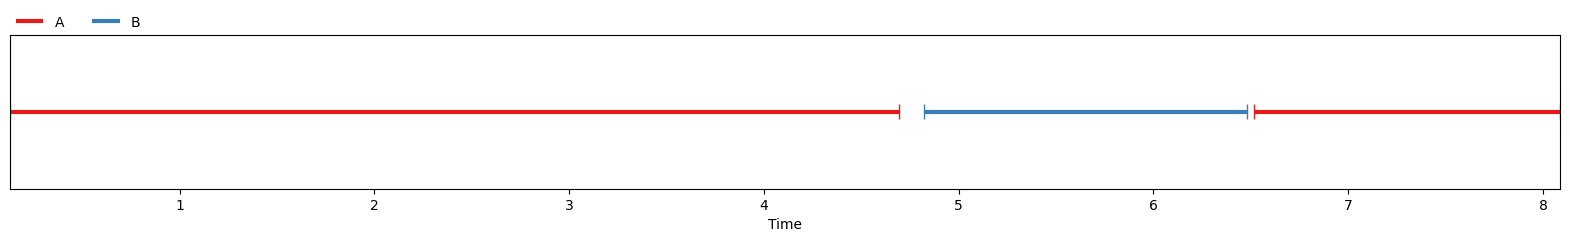

In [6]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(libritts_test(), **config.data.model_dump())
print(audio.shape[-1]/16000)
reference = visualise_annotation(labels)
play(audio)
labels
audio = audio.cuda()

[6.573705196380615, 8.127490043640137, 'A']
[4.9601593017578125, 6.573705196380615, 'B']
[0.23904383182525635, 4.780876636505127, 'A']


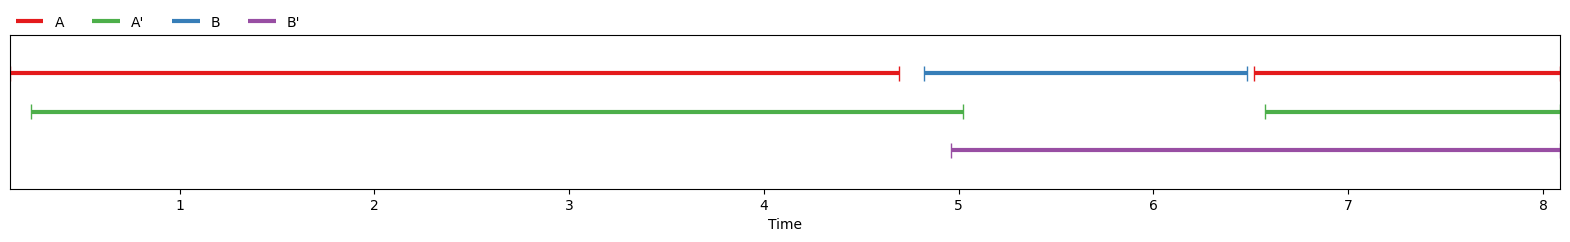

In [10]:
nlabels = model.generate(audio, temperature=1, max_steps=(len(labels))*3)
print("\n".join([str(n) for n in nlabels]))
for l in nlabels:
    l[2] = l[2]+ "'"
hypothesis = visualise_annotation(labels+nlabels)

### Calculate Metrics with Pyannote


In [8]:
from pyannote.core import Annotation
from pyannote.metrics.diarization import DiarizationErrorRate

metric = DiarizationErrorRate()
metric(reference, hypothesis)

/home/harry/diarisation/.venv/lib/python3.10/site-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(


2.508257346230029